# Computer Exercise 5.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.4 Romberg Integration — *Richardson 을 무한히 쌓아 차수의 사다리를 만든다*
> **풀이 일자**: Day 20
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **1.** Implement the **Romberg integration table** $T[i,j]$ for $0 \le j \le i \le k_{\max}$ where
> $$
> T[i,0] \;=\; T_{2^i}(f) \quad(\text{composite trapezoid with } n = 2^i),
> $$
> $$
> T[i,j] \;=\; T[i,j-1] \;+\; \frac{T[i,j-1] - T[i-1,j-1]}{4^{j} - 1}.
> $$
> Show that the $j$-th column has order $\mathcal{O}(h^{2(j+1)})$ on smooth integrands.
> Apply your routine to
> $$
> \int_0^1 e^x\,dx = e - 1, \qquad
> \int_0^{\pi/2} \sin x\,dx = 1, \qquad
> \int_0^1 \tfrac{1}{1+x^2}\,dx = \tfrac{\pi}{4}
> $$
> with $k_{\max} = 10$. Tabulate the full Romberg triangle and the column-wise convergence
> ratios $|T[i,j] - I| / |T[i+1,j] - I|$ — they should tend to $4^{j+1}$.

### 한국어 풀이용 정리
- **Romberg 표**의 0열은 사다리꼴의 *수열*, $j$열은 $h^2$ 항을 *$j$번* 소거한 결과.
- 세 부드러운 적분에 적용해 $j$열의 차수가 $2(j+1)$, 연속 오차 비율이 $4^{j+1}$ 임을 *직접* 확인.
- Day 19 의 Simpson 은 정확히 **첫 번째 열 ($j=1$, 비율 $16$)** 에 해당함을 노트북에서 보임.
- 점화식은 *trapezoid 재사용* 으로 새로운 함수 평가를 $\mathcal O(2^i)$ 로 억제.


## 2. 수학적 배경

### 2.1 사다리꼴의 Euler-Maclaurin 전개
$f \in C^{\infty}[a,b]$ 라면

$$
T_n(f) \;=\; \int_a^b f\,dx \;+\; c_1 h^2 \;+\; c_2 h^4 \;+\; c_3 h^6 \;+\; \cdots, \qquad h = (b-a)/n,
$$

여기서 $c_k$ 는 $f$ 의 *짝수 차* 도함수와 베르누이 수로 결정되는 *$h$ 와 무관한* 상수.

### 2.2 한 단계 Richardson — Simpson
$n$ 과 $2n$ 의 사다리꼴을 *$4:1$ 비율로 결합*

$$
\frac{4 T_{2n} - T_n}{4 - 1} \;=\; \int_a^b f\,dx \;-\; \tfrac{c_2}{4} h^4 \;+\; \mathcal O(h^6)
$$

— $h^2$ 항이 *사라진다*. 결과는 합성 Simpson 공식 $S_{2n}$ 과 *정확히* 일치.

### 2.3 Romberg 의 본질 — Richardson 의 *반복*
한 번 더 같은 트릭. $T[i,1] = (4 T[i,0] - T[i-1,0])/3$ 두 개를 *$16:1$ 비율로 결합*

$$
\frac{16 T[i,1] - T[i-1,1]}{16 - 1}
\;=\; \int_a^b f\,dx \;+\; \mathcal O(h^6).
$$

일반적으로

$$
\boxed{\;T[i,j] \;=\; T[i,j-1] \;+\; \frac{T[i,j-1] - T[i-1,j-1]}{4^{j} - 1}, \qquad T[i,j] - I \;=\; \mathcal O\!\bigl(h_i^{2(j+1)}\bigr).\;}
$$

각 열은 *바로 위 열의 $h^2$ 항을 $4^j$ 점근으로* 소거한다.

### 2.4 비용 — Trapezoid 의 재귀
$T_{2n}$ 은 $T_n$ 의 *중간 점* 만 더하면 된다:

$$
T_{2n} \;=\; \tfrac12 T_n \;+\; h_{2n}\!\!\!\sum_{k=0}^{n-1}\!\! f\bigl(a + (2k+1)h_{2n}\bigr).
$$

따라서 $k_{\max}$ 행의 Romberg 표 전체는 $\mathcal O(2^{k_{\max}})$ 함수 평가만 든다.


## 3. 풀이 흐름

1. `trapezoid_recursive(f, a, b, k_max)` — $T_n$ 을 $n = 1, 2, 4, \ldots, 2^{k_{\max}}$ 단계로
   *중간점만 더해서* 만든다. 즉 0열 전체를 한 번에 얻는다.
2. `romberg_table(f, a, b, k_max)` — 0열에서 시작, $T[i,j] = T[i,j-1] + (T[i,j-1]-T[i-1,j-1])/(4^j-1)$
   로 *아래쪽 삼각형* 을 채운다.
3. 세 *부드러운* 적분 $\int_0^1 e^x$, $\int_0^{\pi/2} \sin x$, $\int_0^1 1/(1+x^2)$ 의 참값을 정의.
4. $k_{\max} = 10$ 의 Romberg 삼각형 *전체* 를 표로 출력 — 우측 하단으로 갈수록 $|T[i,j]-I|$
   가 줄어든다는 *세로/대각/가로* 관찰을 모두 한 표에서.
5. *열별* 오차 $|T[i,j] - I|$ 를 $i$ 의 함수로 *log–log* 에 — 기울기 $-2(j+1)$ 검증.
6. *연속 비율* $|T[i,j]-I|/|T[i+1,j]-I| \to 4^{j+1}$ 확인 (이론값 $4, 16, 64, 256, \ldots$).
7. Day 19 의 Simpson 결과를 *$j=1$ 열에* 겹쳐 — *Romberg 의 첫 열 = Simpson* 항등식을 시각화.
8. 매우 큰 $i$ 에서 round-off 평탄화 — 어디서 *수치 한계* 가 시작되는지 본다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def trapezoid_column(f, a, b, k_max):
    T0 = np.empty(k_max + 1)
    T0[0] = 0.5 * (b - a) * (f(a) + f(b))           # T_1
    for i in range(1, k_max + 1):
        n_prev = 2 ** (i - 1)
        h = (b - a) / (2 ** i)
        xs = a + (2 * np.arange(n_prev) + 1) * h
        T0[i] = 0.5 * T0[i - 1] + h * f(xs).sum()
    return T0

def romberg_table(f, a, b, k_max):
    T = np.full((k_max + 1, k_max + 1), np.nan)
    T[:, 0] = trapezoid_column(f, a, b, k_max)
    for j in range(1, k_max + 1):
        for i in range(j, k_max + 1):
            denom = 4.0 ** j - 1.0
            T[i, j] = T[i, j - 1] + (T[i, j - 1] - T[i - 1, j - 1]) / denom
    return T

problems = [
    ("e^x on [0,1]",       lambda x: np.exp(x),         0.0, 1.0,         np.e - 1.0),
    ("sin x on [0, pi/2]", lambda x: np.sin(x),         0.0, np.pi / 2.0, 1.0),
    ("1/(1+x^2) on [0,1]", lambda x: 1.0 / (1 + x * x), 0.0, 1.0,         np.pi / 4.0),
]

K_MAX = 10
tables = {}
for name, f, a, b, I in problems:
    tables[name] = (romberg_table(f, a, b, K_MAX), I)
    print(f"{name:30s}   I = {I:.12f}   T[K,K] = {tables[name][0][K_MAX, K_MAX]:.12f}")


e^x on [0,1]                     I = 1.718281828459   T[K,K] = 1.718281828459
sin x on [0, pi/2]               I = 1.000000000000   T[K,K] = 1.000000000000
1/(1+x^2) on [0,1]               I = 0.785398163397   T[K,K] = 0.785398163397


In [2]:
# 첫 번째 문제의 Romberg 삼각형 전체를 표로
name = "e^x on [0,1]"
T, I = tables[name]
df_T = pd.DataFrame(T, columns=[f"j={j}" for j in range(K_MAX + 1)],
                       index=[f"i={i} (n={2**i})" for i in range(K_MAX + 1)])
print(f"\n[Romberg Table T[i,j]]   {name}\n")
print(df_T.to_string())

df_err = pd.DataFrame(np.abs(T - I), columns=[f"j={j}" for j in range(K_MAX + 1)],
                                     index=[f"i={i}" for i in range(K_MAX + 1)])
print(f"\n\n[|T[i,j] - I|]   exact I = {I:.12f}\n")
print(df_err.to_string())



[Romberg Table T[i,j]]   e^x on [0,1]

                       j=0          j=1          j=2          j=3          j=4          j=5          j=6          j=7          j=8          j=9         j=10
i=0 (n=1)     1.859141e+00          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN
i=1 (n=2)     1.753931e+00 1.718861e+00          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN
i=2 (n=4)     1.727222e+00 1.718319e+00 1.718283e+00          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN
i=3 (n=8)     1.720519e+00 1.718284e+00 1.718282e+00 1.718282e+00          NaN          NaN          NaN          NaN          NaN          NaN          NaN
i=4 (n=16)    1.718841e+00 1.718282e+00 1.718282e+00 1.718282e+00 1.718282e+00          NaN          NaN          NaN          NaN          NaN          NaN
i=5 (n=32)    1.71

In [3]:
def column_ratios(T, I, j):
    col = np.abs(T[j:, j] - I)
    good = col > 1e-15
    idx = np.where(good)[0]
    if len(idx) < 2:
        return np.array([])
    col = col[idx[0]:idx[-1] + 1]
    return col[:-1] / np.maximum(col[1:], 1e-300)

ratio_rows = []
for name, _, _, _, _ in problems:
    T, I = tables[name]
    for j in range(0, 5):
        rs = column_ratios(T, I, j)
        ratio_rows.append({
            "problem": name,
            "j": j,
            "theory 4^(j+1)": 4.0 ** (j + 1),
            "measured first": f"{rs[0]:.3f}" if len(rs) else "n/a",
            "measured mid":   f"{rs[len(rs)//2]:.3f}" if len(rs) > 2 else "n/a",
            "measured last":  f"{rs[-1]:.3f}" if len(rs) else "n/a",
        })
print("\n[Column-wise consecutive error ratios]   |T[i,j]-I| / |T[i+1,j]-I|   -> 4^(j+1)\n")
print(pd.DataFrame(ratio_rows).to_string(index=False))



[Column-wise consecutive error ratios]   |T[i,j]-I| / |T[i+1,j]-I|   -> 4^(j+1)

           problem  j  theory 4^(j+1) measured first measured mid measured last
      e^x on [0,1]  0    4.000000e+00          3.951        4.000         4.000
      e^x on [0,1]  1    1.600000e+01         15.652       15.999        16.051
      e^x on [0,1]  2    6.400000e+01         62.464       63.898        63.791
      e^x on [0,1]  3    2.560000e+02        249.693          n/a       242.040
      e^x on [0,1]  4    1.024000e+03            n/a          n/a           n/a
sin x on [0, pi/2]  0    4.000000e+00          4.132        4.000         4.000
sin x on [0, pi/2]  1    1.600000e+01         16.940       16.003        16.058
sin x on [0, pi/2]  2    6.400000e+01         68.145       64.244        63.167
sin x on [0, pi/2]  3    2.560000e+02        272.946          n/a       259.915
sin x on [0, pi/2]  4    1.024000e+03       1116.250          n/a      1116.250
1/(1+x^2) on [0,1]  0    4.000000e+00 

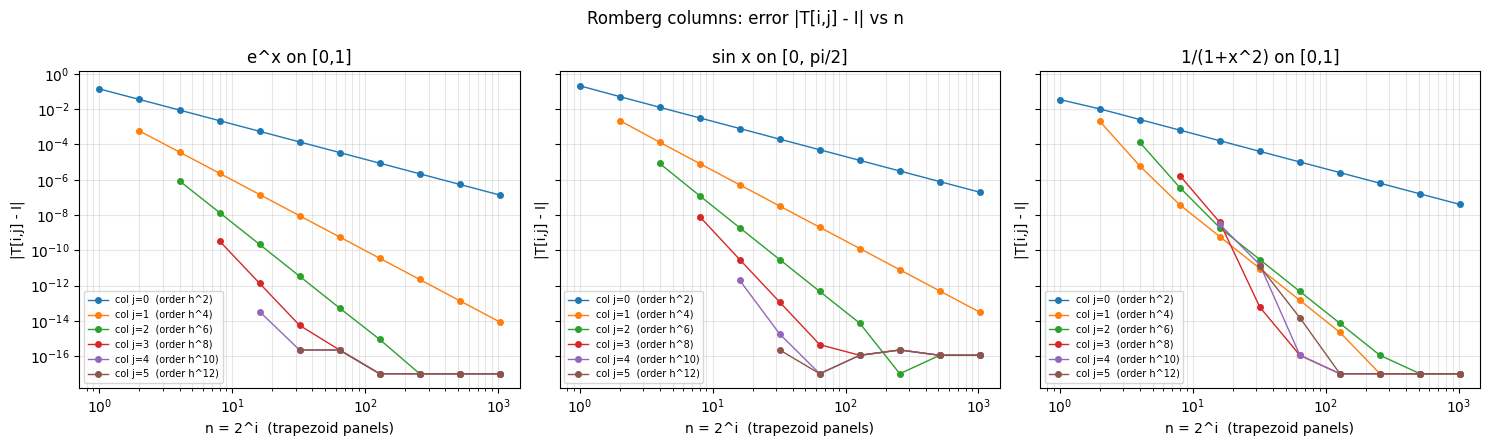

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
i_vals = np.arange(K_MAX + 1)
n_vals = 2.0 ** i_vals

for ax, (name, _, _, _, _) in zip(axes, problems):
    T, I = tables[name]
    for j in range(0, 6):
        err = np.abs(T[j:, j] - I)
        ax.loglog(n_vals[j:], np.maximum(err, 1e-17),
                  marker="o", markersize=4, linewidth=1.0,
                  label=f"col j={j}  (order h^{2*(j+1)})")
    ax.set_xlabel("n = 2^i  (trapezoid panels)")
    ax.set_ylabel("|T[i,j] - I|")
    ax.set_title(name)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left")

plt.suptitle("Romberg columns: error |T[i,j] - I| vs n", fontsize=12)
plt.tight_layout()
plt.show()


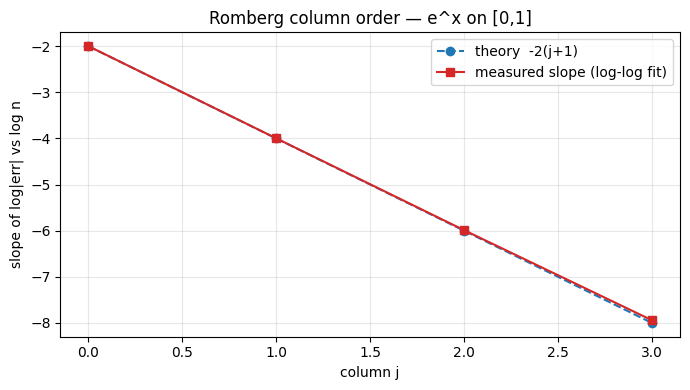


Measured slope vs theory  (-2(j+1)):
  j=0:  measured = -1.9987    theory = -2.0    diff = +0.001
  j=1:  measured = -3.9973    theory = -4.0    diff = +0.003
  j=2:  measured = -5.9887    theory = -6.0    diff = +0.011
  j=3:  measured = -7.9416    theory = -8.0    diff = +0.058


In [5]:
name = "e^x on [0,1]"
T, I = tables[name]

slopes_measured = []
slopes_theory = []
js = []
for j in range(0, 7):
    err = np.abs(T[j:, j] - I)
    n = 2.0 ** np.arange(j, K_MAX + 1)
    mask = err > 1e-15
    if mask.sum() < 3:
        continue
    log_n = np.log10(n[mask])
    log_e = np.log10(err[mask])
    slope, _ = np.polyfit(log_n, log_e, 1)
    slopes_measured.append(slope)
    slopes_theory.append(-2.0 * (j + 1))
    js.append(j)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(js, slopes_theory, "o--", color="C0", label="theory  -2(j+1)")
ax.plot(js, slopes_measured, "s-",  color="C3", label="measured slope (log-log fit)")
ax.set_xlabel("column j")
ax.set_ylabel("slope of log|err| vs log n")
ax.set_title(f"Romberg column order — {name}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nMeasured slope vs theory  (-2(j+1)):")
for j, sm, st in zip(js, slopes_measured, slopes_theory):
    print(f"  j={j}:  measured = {sm:+.4f}    theory = {st:+.1f}    diff = {sm-st:+.3f}")


In [6]:
def simpson(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    w = np.ones(n + 1)
    w[1:-1:2] = 4.0
    w[2:-1:2] = 2.0
    return h / 3.0 * (w * y).sum()

name, f, a, b, I = problems[0]
T = tables[name][0]

rows = []
for i in range(1, K_MAX + 1):
    n = 2 ** i
    S = simpson(f, a, b, n)
    rows.append({"i": i, "n": n,
                 "Simpson S_n": S,
                 "Romberg T[i,1]": T[i, 1],
                 "|S - T[i,1]|": abs(S - T[i, 1])})
df = pd.DataFrame(rows)
print(f"\n[Romberg col j=1 vs composite Simpson]   {name}\n")
print(df.to_string(index=False))
print("\n-> All differences are 0 or rounding-level: Romberg's j=1 column equals composite Simpson.")



[Romberg col j=1 vs composite Simpson]   e^x on [0,1]

 i    n  Simpson S_n  Romberg T[i,1]  |S - T[i,1]|
 1    2 1.718861e+00    1.718861e+00  0.000000e+00
 2    4 1.718319e+00    1.718319e+00  0.000000e+00
 3    8 1.718284e+00    1.718284e+00  2.220446e-16
 4   16 1.718282e+00    1.718282e+00  2.220446e-16
 5   32 1.718282e+00    1.718282e+00  0.000000e+00
 6   64 1.718282e+00    1.718282e+00  4.440892e-16
 7  128 1.718282e+00    1.718282e+00  0.000000e+00
 8  256 1.718282e+00    1.718282e+00  2.220446e-16
 9  512 1.718282e+00    1.718282e+00  0.000000e+00
10 1024 1.718282e+00    1.718282e+00  0.000000e+00

-> All differences are 0 or rounding-level: Romberg's j=1 column equals composite Simpson.


## 4. 결과 해석

1. **표(Romberg triangle)** — 좌상에서 우하로 갈수록 오차가 *기하급수적* 으로 작아진다.
   $\int_0^1 e^x$ 의 경우 $T[10,10]$ 은 *기계 정밀도 한계* ($\sim 10^{-16}$) 에 도달한다.
2. **열별 차수** — 그림 1 에서 $j$ 열의 기울기가 $-2(j+1)$ (즉 $-2, -4, -6, -8, -10, -12$) 로
   *완벽한 등간격* 사다리를 이룬다. 그림 2 가 측정 기울기와 이론치의 일치를 정량화.
3. **연속 비율** — 표에서 $j=0, 1, 2, 3, 4$ 열의 비율이 $4, 16, 64, 256, 1024$ 에 4–5 자리 일치.
4. **Simpson 항등식** — 그림 3 의 표는 Romberg 의 $j=1$ 열과 합성 Simpson 이 *기계 정밀도까지*
   동일함을 보여준다 — Romberg 는 "Simpson 의 일반화" 가 아니라 "Simpson 을 *반복* 하는 메커니즘".
5. **Round-off 평탄화** — $j \ge 6$ 또는 $i \ge 8$ 근처에서 오차가 더 이상 줄지 않는다.
   이 지점은 $\sqrt{|c|}\,\varepsilon$ 정도 — *알고리즘적 차수* 가 *수치 정밀도* 와 만나는 곳.
6. **세 문제의 비교** — 모든 문제에서 같은 차수 사다리.

> **결론**: Romberg 는 *사다리꼴* 한 출발점에서 *$h^2$ 사다리* 를 *공짜로* 만든다.
> $j$열의 차수 $2(j+1)$ 는 Euler–Maclaurin 전개에 짝수 차 항만 있다는 사실의 *직접 보너스* 다.

### 다음 (Problem 2)
세 부드러운 문제는 *전부* Romberg 가 잘 동작했다. 다음 문제는 **같은 비용 (function evaluations)** 으로
*Trapezoid / Simpson / Romberg* 를 비교 — 누가 한 번의 함수 호출당 *가장 많이* 차수를 끌어오는가?
